# MAE3405 Assignment 3 - 2026

Dr Daniel Duke

Department of Mechanical & Aerospace Engineering

Monash University

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline


## Step 1. Define functions for each stage of a turbofan engine.

In [162]:
def standardAtmosphereDensity(z_km):

    return -3.32423E-05*z_km**3 + 3.45829E-03*z_km**2 - 1.12528E-01*z_km + 1.21953E+00

    '''
    if isinstance(z_km,float):
        r = np.roots((6.10767, -2.20467e1, 1.79402e1-z_km))
        r = r[(r>0)&(r<1.3)]
        return np.min(r)
    else:
        output=[]
        for z_ in z_km:
            r = np.roots((6.10767, -2.20467e1, 1.79402e1-z_))
            r = r[(r>0)&(r<1.3)]
            output.append(np.min(r))
        return np.array(output)
    '''

def standardAtmosphereTemp(z_km):
    # Includes tropopause, good up to 22.5 km (same as MAE3405 notes)
    T = -6.5*z_km + 2.8815e2
    if isinstance(T,float):
        if (z_km>11)&(z_km<=20): return 216.65
        elif z_km>20: return 1.*z_km + 1.9665e2 
        else: return T
    else: # list, array
        T[z_km>=11.] = 216.65
        T[z_km>20.] = 1.*z_km[z_km>20.] + 1.9665e2 
    return T

def standardAtmospherePress(z_km):
    # up to 22.5km fitted polynomial
    return 6.49065E-02*z_km**4 - 1.04668E+01*z_km**3 + 5.37962E+02*z_km**2 - 1.18797E+04*z_km + 1.01237E+05
    #return 287. * standardAtmosphereDensity(z_km) * standardAtmosphereTemp(z_km)

In [25]:
def airspeed(Mach,Ta,k=1.4):
    # Return airspeed (m/s) given Mach number
    SoS = np.sqrt(k*287*Ta)
    return SoS*Mach
    
def subsonicIntake(pa,Ta,Mach,isen_intake=0.95,k=1.4,Cp=1005):
    # Return stagnation pressure and temperature through a subsonic gas turbine intake
    RamPressureRatio = (0.5*isen_intake*(k-1)*(Mach**2)+1)**(k/(k-1))
    p01 = pa * RamPressureRatio
    C = airspeed(Mach,Ta,k)
    T01 = Ta + (C**2)/(2*Cp)
    return p01,T01

In [44]:
def compressor(p01,T01,pressureRatio,isentropic_efficiency=0.85,k=1.4,Cp=1005):
    # Return stagnation pressure and temperature through a subsonic compressor
    tempRatio = 1 + (pressureRatio**((k-1)/k) - 1)/isentropic_efficiency
    T02 = T01*tempRatio
    specificWork = Cp*(T02-T01)
    return p01*pressureRatio, T02, specificWork

In [597]:
def combustorOutput(p02,T02,f,pressureDrop=0.02,combustionEfficiency=0.98,LHV=43.1e6,Cpa=1005,Cpg=1148):
    # Return outlet stagnation pressure and temperature through a subsonic burner given fuel-air ratio etc.
    p03 = p02*(1-pressureDrop)
    Qburner = LHV*combustionEfficiency*f #J/kg
    h_in=Cpa*(T02-298) #J/kg
    h_out=h_in+Qburner
    T03=(h_out/(Cpg*(1+f))) + 298
    return p03,T03

def combustorFuelAir(T02,T03,pressureDrop=0.02,combustionEfficiency=0.98,LHV=43.1e6,Cpa=1005,Cpg=1148):
    # Return fuel-air ratio required to deliver  certain output stagnation temperature for a burner.
    h_in=Cpa*(T02-298) #J/kg
    h_out=Cpg*(T03-298) #J/kg divided by (1+f)
    
    #LHV*combustionEfficiency*f = h_out*(1+f)-h_in
    #f(LHV*combustionEfficiency - h_out) = h_out-h_in
    f = (h_out-h_in) / (LHV*combustionEfficiency - h_out)
    return f

In [598]:
def turbineOutput(p03,T03,WT,isentropic_efficiency=0.85,Cp=1148,k=1.333):
    # Return the output stagnation pressure and temperature of a turbine
    #if the specific work extracted from the working fluid is known.
    # The turbine work must already account for spool losses and mass flow ratios.
    T04 = T03 - (WT/Cp)
    T04_isen = T03 - ((T03 - T04)/isentropic_efficiency)

    # Check for insufficient gas temperature to produce the requested work
    if isinstance(T04_isen,float):
        if T04_isen<0: T04_isen=np.nan
    else:
        T04_isen[T04_isen<0]=np.nan
    
    pressureRatio = (T04_isen/T03)**(k/(k-1))
    p04 = p03*pressureRatio
    return p04, T04

def turbineWork(p03,T03,p04,isentropic_efficiency=0.85,Cp=1148,k=1.333):
    # Return the output specific work of a turbine
    #if the downstream pressure is set (i.e. by the nozzle or duct).
    tempRatio = 1 + ((p04/p03)**((k-1)/k) - 1)/isentropic_efficiency
    T04 = T03*tempRatio
    WT = Cp*(T03-T04)
    return WT # J/kg turbine flow, not accounting for any spool loss or mass flow ratios.

In [603]:
def fbound(x):
    # Return NaN if the argument to a sqrt is negative, without runtime warning.
    if isinstance(x,float):
        if x>0: return x
        else: return np.nan #x*(x>0)
    else:
        y=x[...]
        y[x<0]=np.nan
        return y
    
def convergentNozzle(p0,T0,pa,Cp=1005,k=1.4,R=287.,isen_nozzle=0.95):
    # Return specific thrust of a choked or unchoked convergent nozzle
    criticalPressureRatio = (1-((k-1)/(k+1)/isen_nozzle))**(-k/(k-1))
    nozzlePressureRatio = p0/pa
    choked = nozzlePressureRatio>criticalPressureRatio
    
    Tj_unchoked = T0-isen_nozzle*(T0-(T0*(1/nozzlePressureRatio)**((k-1)/k)))
    Cj_unchoked = np.sqrt(fbound(T0-Tj_unchoked)*2*Cp)
    pj_unchoked = pa
    Fs_unchoked = Cj_unchoked # specific gross thrust
    
    Tj_choked = 2*T0/(k+1)
    Cj_choked = np.sqrt(fbound(k*R*Tj_choked))
    pj_choked = p0/criticalPressureRatio
    rhoj = pj_choked / (R*Tj_choked)
    Fs_choked = Cj_choked + (pj_choked-pa)/(rhoj*Cj_choked + 1e-12) # specific gross thrust
    
    
    if isinstance(p0,float):
        if choked: 
            return Tj_choked, Cj_choked, pj_choked, Fs_choked, choked
        else: 
            return Tj_unchoked, Cj_unchoked, pj_unchoked, Fs_unchoked, choked
    else: # vector
        Tj = Tj_unchoked[...]
        Cj = Cj_unchoked[...]
        pj = pj_unchoked[...]
        Fs = Fs_unchoked[...]
        Tj[choked] = Tj_choked[choked]
        Cj[choked] = Cj_choked[choked]
        pj[choked] = pj_choked[choked]
        Fs[choked] = Fs_choked[choked]
        return Tj, Cj, pj, Fs, choked

## Step 2. Make a function for my specific engine cycle

Twin spool turbofan with the fan and LPC driven by the LPT, HPC driven by HPT.

In [744]:
def myEngine(z_km=0,Mach=0.75,FPR=1.75,CPR_L=2,OPR=32.,f=0.03,\
             B=4.9,eta_spool=.99,D_in=2.54):

    ''' twin-spool turbofan with two stage compressor '''
    '''     solve for fixed Mach and fuel-air ratio   '''
    
    pa = standardAtmospherePress(z_km) # atmosphere
    Ta = standardAtmosphereTemp(z_km)
    rho_a = standardAtmosphereDensity(z_km)
    
    p01,T01=subsonicIntake(pa,Ta,Mach) # intake
    
    p02,T02,WF=compressor(p01,T01,FPR) # fan
    
    p03,T03,WC1=compressor(p02,T02,CPR_L) # low pressure compressor
    
    CPR_H=OPR/(FPR*CPR_L) # high pressure compressor
    p04,T04,WC2=compressor(p02,T02,CPR_H) # high pressure compressor
    
    p05,T05=combustorOutput(p04,T04,f) # burner, given fixed A/F
    
    #HPT work (it drives the HPC)
    W_HPT = WC2/(eta_spool*(1+f))
    p06,T06=turbineOutput(p05,T05,W_HPT) # HPT
    
    #LPT work (it drives fan + LPC)
    W_LPT = ( WF*(B+1) + WC1 )/(eta_spool*(1+f))
    p07,T07=turbineOutput(p06,T06,W_LPT) # LPT
    #print(p07,T07)
    
    # Cold nozzle (from fan output at p02,T02)
    Tc,Cc,pc,Fsc,chkc = convergentNozzle(p02,T02,pa,Cp=1005,k=1.4)

    # Hot nozzle (from LPT output at p07,T07)
    Th,Ch,ph,Fsh,chkh = convergentNozzle(p07,T07,pa,Cp=1148,k=1.333)

    # Engine mass flow
    A_in = 0.25*np.pi*(D_in**2)
    C_in = airspeed(Mach,Ta)
    mdot_engine = rho_a*A_in*C_in

    # Check for positive thrust (C nozzle > airspeed)
    '''
    if isinstance(Cc,float):
        if Cc-C_in<0: Fsc=np.nan
        #if Ch-C_in<0: Fsh=np.nan
    else:
        Fsc[Cc-C_in<0]=np.nan
        #Fsh[Ch-C_in<0]=np.nan
    '''
    
    # Bypass and core mass flows
    mdot_jhot = (1+f)*mdot_engine/(B+1)
    mdot_cold = mdot_engine*B/(B+1)
    mdot_fuel = f*mdot_engine/(B+1)

    # Gross and Net thrust
    Fhot = Fsh*mdot_jhot*1e-3 # kN
    Fcold = Fsc*mdot_cold*1e-3 # kN
    Fram = C_in*mdot_engine*1e-3 # kN
    Fnet = Fhot+Fcold-Fram

    TSFC = 1e3*mdot_fuel/Fnet # g/kN-s
    
    return Fnet, TSFC, (Fhot, Fcold, Fram, chkc, chkh, mdot_fuel)

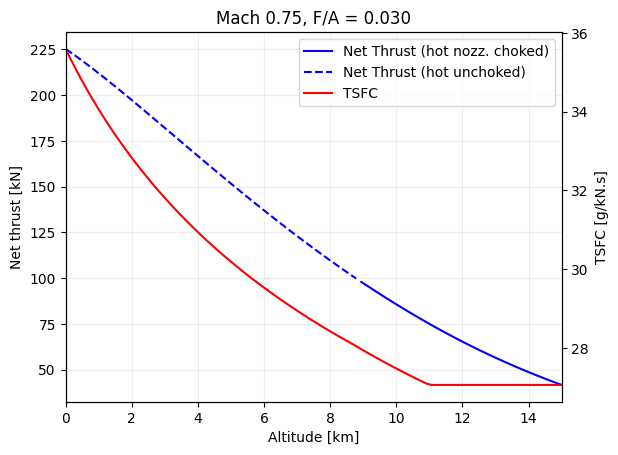

In [760]:
z = np.linspace(0,15,100)
f=0.03
M=0.75
Fnet,TSFC,etc = myEngine(z,Mach=M,f=f)
etc=np.array(etc)

chkh = etc[4,:].astype(bool)

fig=plt.figure()
plt.title("Mach %.2f, F/A = %.3f" % (M,f));
p0,=plt.plot(z[chkh],Fnet[chkh],label='Net Thrust (hot nozz. choked)',c='b');
p1,=plt.plot(z[~chkh],Fnet[~chkh],label='Net Thrust (hot unchoked)',c='b',ls='--');
plt.ylabel('Net thrust [kN]')
plt.xlabel('Altitude [km]');
plt.grid(alpha=.2)
plt.xlim(z.min(),z.max());
plt.twinx();
p2,=plt.plot(z,TSFC,label='TSFC',c='r');
plt.ylabel('TSFC [g/kN.s]');
#plt.axhline(16.1,ls=':',c='r')
#plt.plot(z,etc[0,:],ls=':',label='Fhot');
#plt.plot(z,etc[1,:],ls=':',label='Fcold');
#plt.plot(z,etc[2,:],ls=':',label='Fram');plt.legend();
plt.legend([p0,p1,p2],[p.get_label() for p in [p0,p1,p2]]);

## Part 3. Maximum Mach vs Altitude

Determine how high Mach can be and still produce positive thrust at any altitude.
Since we assume a fixed OPR and F/A, this is just determined by the balance of airspeed and nozzle velocity



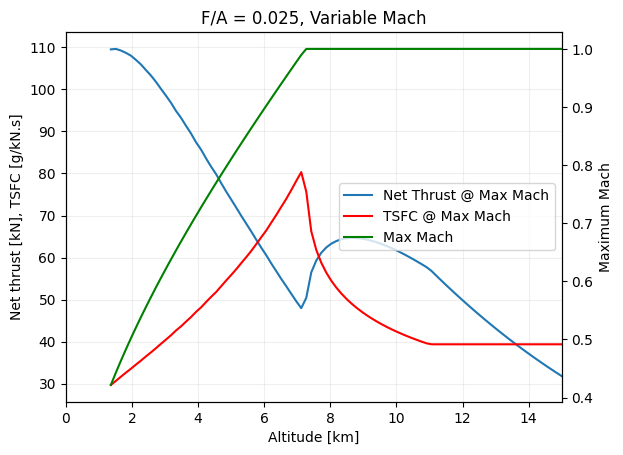

In [762]:
Fnet=[]
TSFC=[]
Mach=[]
etc=[]
f=0.025
for z_ in z:
    M_=np.arange(1,0,-0.00001)
    
    Fnet_,TSFC_,e_ = myEngine(z_*np.ones_like(M_),M_,f=f)
    
    i = np.where(~np.isnan(Fnet_))[0]
    if len(i) == 0: 
        Fnet.append(np.nan)
        TSFC.append(np.nan)
        Mach.append(np.nan)
        etc.append([np.nan]*len(e_))
    else:
        Fnet.append(Fnet_[i[0]])
        TSFC.append(TSFC_[i[0]])
        Mach.append(   M_[i[0]])
        etc.append( [ e__[i[0]] for e__ in e_ ] )

etc=np.array(etc)

fig=plt.figure()
plt.title("F/A = %.3f, Variable Mach" % f);
p0,=plt.plot(z,Fnet,label='Net Thrust @ Max Mach');
plt.ylabel('Net thrust [kN], TSFC [g/kN.s]')
plt.xlabel('Altitude [km]');
#plt.plot(z,etc[:,0],ls='--',label='Fhot');
#plt.plot(z,etc[:,1],ls='--',label='Fcold');
#plt.plot(z,etc[:,2],ls='--',label='Fram');
plt.grid(alpha=.2)
plt.xlim(z.min(),z.max());
p1,=plt.plot(z,TSFC,label='TSFC @ Max Mach',c='r');

#plt.legend();

plt.twinx();
p2,=plt.plot(z,Mach,label='Max Mach',c='g')
plt.ylabel('Maximum Mach');
#plt.plot(z,etc[:,5],ls='--',label='mdot fuel');
plt.legend([p0,p1,p2],[p.get_label() for p in [p0,p1,p2]], loc='right');